# Stage1 / 02b — Lane + detection diagnostics

Scientific debug notebook for stage1 sanity. Run AFTER notebook 02 has
produced a few epochs of training (or during a fresh smoke run).

Answers the four questions that decide whether stage1 is salvageable:

1. **Does the dataloader actually emit lane foreground pixels?**
   Foreground-ratio histogram across a batch.
2. **Do the lane logits / probabilities move when we train?**
   min / max / mean of `sigmoid(fg_logits)` at init vs after training.
3. **Can the model overfit 16 samples on the lane task alone?**
   If no — supervision, geometry, or loss is broken; the model itself
   is not the problem.
4. **Is the det head actually predicting anywhere near GT?**
   Batch visualization of image / GT boxes / predicted boxes / GT lane /
   predicted lane on 4 held-out samples.

This notebook is READ-ONLY w.r.t. stage1 checkpoints — it never
overwrites them. It loads `best_joint.pth` by default; override via
the `CKPT_NAME` variable in cell 3.


In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q yacs tqdm opencv-python-headless

import os, sys
REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

Mounted at /content/drive


In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torch.utils.data import DataLoader

from lib.config import cfg
from lib.models import get_net
from lib.core import get_loss
from lib.dataset import BddDataset
from lib.utils.drive_dataset import (
    ensure_local_dataset_from_drive, find_raw_bdd_root,
    resolve_bdd_images_100k_dir, resolve_bdd_labels_100k_dir,
)

CONFIG = 'YOLOP'
CKPT_NAME = 'best_joint.pth'    # 'best_joint.pth' | 'best_det.pth' | 'best_lane.pth' | 'latest.pth' | None

yaml_map = {
    'YOLOPv2-paper-no-da': os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopv2_paper_no_da.yaml'),
    'YOLOPv2-best-row':   os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopv2_best_row.yaml'),
    'YOLOPv2-focal-only': os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopv2_focal_only_ablation.yaml'),
    'YOLOP':              os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolop_vehicle_lane_baseline.yaml'),
}
cfg.defrost()
cfg.merge_from_file(yaml_map[CONFIG])

ECOCAR_ROOT = '/content/drive/MyDrive/EcoCAR'
DATASET_ROOT = ensure_local_dataset_from_drive('bdd100k_vehicle5', ECOCAR_ROOT)
RAW_BDD_ROOT = find_raw_bdd_root(ECOCAR_ROOT)
cfg.DATASET.ROOT = DATASET_ROOT
cfg.DATASET.DATAROOT = resolve_bdd_images_100k_dir(RAW_BDD_ROOT)
cfg.DATASET.LABELROOT = resolve_bdd_labels_100k_dir(RAW_BDD_ROOT)
cfg.DATASET.LANEROOT = os.path.join(DATASET_ROOT, 'masks')
cfg.TEST.PLOTS = False
cfg.freeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Config:', CONFIG)
print('NC=', cfg.MODEL.NC, '  protocol=', cfg.DATASET.CLASS_PROTOCOL)
print('Device:', device)

Extracting /content/drive/MyDrive/EcoCAR/datasets/bdd100k_vehicle5.tar.gz into this notebook runtime ...
Config: YOLOP
NC= 1   protocol= stage1_vehicle_merged
Device: cuda


In [3]:
# ── Build small val dataset + optional checkpoint load ──
val_wh = tuple(cfg.TEST.IMAGE_SIZE)    # (W, H)
val_size = (int(val_wh[1]), int(val_wh[0]))
val_dataset = BddDataset(cfg, is_train=False, inputsize=val_size, transform=T.ToTensor())
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False,
                        num_workers=0, collate_fn=val_dataset.collate_fn)

model = get_net(cfg).to(device)
model.gr = 1.0

ckpt_path = os.path.join(cfg.DRIVE.CHECKPOINT_DIR, CKPT_NAME) if CKPT_NAME else None
if ckpt_path and os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['state_dict'])
    print(f'Loaded {CKPT_NAME} at epoch {ckpt["epoch"]}  '
          f'mAP50={ckpt.get("mAP50", "?")}  ll_iou={ckpt.get("ll_iou", "?")}')
else:
    print('[info] no checkpoint found — diagnostics will reflect random init')

[Dataset] split=val | layout=explicit_packaged_like
[Dataset] images=/content/bdd100k_raw/100k/val
[Dataset] labels=/content/bdd100k_raw/100k/val
[Dataset] lanes =/content/bdd100k_vehicle5/masks/val
building database...


100%|██████████| 10000/10000 [00:00<00:00, 10204.80it/s]


database build finish: 10000 samples
missing lane masks skipped: 0
missing detection labels: 0
Loaded best_joint.pth at epoch 90  mAP50=0.7264516920861266  ll_iou=0.23403060112003632


## 1) Lane GT foreground-ratio statistics

If `mean fg_ratio` across a batch is ~0 or ~1, the lane mask generator is
broken. For BDD-scale 384×640 letterboxed images with 8-pixel lines, the
expected per-image fg ratio is roughly **0.5 % – 5 %**.

In [4]:
img, target, paths, shapes = next(iter(val_loader))
lane = target[1]           # [B, 2, H, W] in [0,1]
fg = lane[:, 1]
ratios = fg.reshape(fg.shape[0], -1).mean(dim=1).cpu().numpy()
print('fg ratio per image:', np.round(ratios, 4).tolist())
print(f'mean fg ratio = {ratios.mean():.4f}  (healthy range ≈ 0.005 – 0.05)')

fg ratio per image: [0.004999999888241291, 0.007799999788403511, 0.0031999999191612005, 0.0010000000474974513, 0.0008999999845400453, 0.0015999999595806003, 0.0012000000569969416, 0.0024999999441206455]
mean fg ratio = 0.0029  (healthy range ≈ 0.005 – 0.05)


## 2) Lane probability statistics from the model

At random init, `sigmoid(fg_logit)` should be ~0.5 everywhere (bias
prior). After meaningful training, max should be > 0.5 on real lane
pixels. If max stays at ~0.5 after training, the lane decoder weights
are frozen or receiving no gradient.

In [5]:
model.eval()
with torch.no_grad():
    img_d = img.to(device)
    det_out, lane_logits = model(img_d)
    fg_prob = torch.sigmoid(lane_logits[:, 0]) if lane_logits.shape[1] == 1 else torch.sigmoid(lane_logits[:, 1])
    p = fg_prob.detach().cpu().numpy()
print(f'fg_prob  min = {p.min():.4f}   max = {p.max():.4f}   mean = {p.mean():.4f}')
print(f'fg_prob  >0.5 pixel ratio = {(p > 0.5).mean():.4f}')
print(f'fg_prob  >0.7 pixel ratio = {(p > 0.7).mean():.4f}')

fg_prob  min = 0.4073   max = 1.0000   mean = 0.4200
fg_prob  >0.5 pixel ratio = 0.0167
fg_prob  >0.7 pixel ratio = 0.0084


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## 3) Overfit 16 samples on lane task alone

Freeze the detection head (set det loss gains to 0 via LANE_ONLY), train for
300 iterations on a tiny subset with a moderate LR, and watch the soft-IoU
loss trend down. If it does not, the lane pipeline has a real bug — the
model itself is sound. If it does, the bug is in the full training
schedule (optimizer / warmup / dataset shuffle / etc.).

[Dataset] split=train | layout=explicit_packaged_like
[Dataset] images=/content/bdd100k_raw/100k/train
[Dataset] labels=/content/bdd100k_raw/100k/train
[Dataset] lanes =/content/bdd100k_vehicle5/masks/train
building database...


100%|██████████| 70000/70000 [00:06<00:00, 10200.65it/s]


database build finish: 70000 samples
missing lane masks skipped: 0
missing detection labels: 0


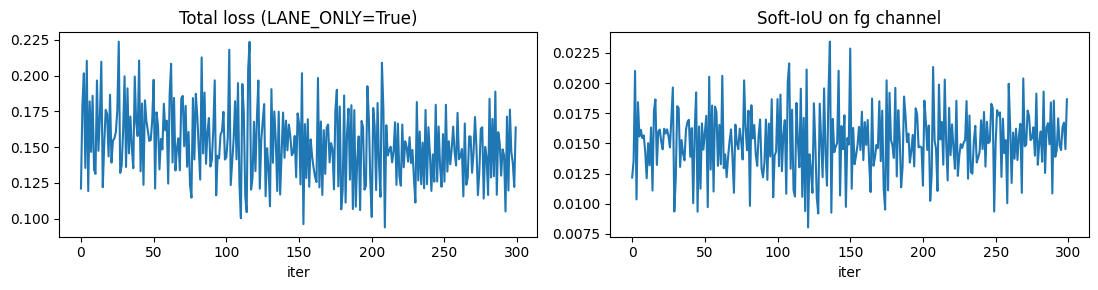

Final IoU on tiny subset: 0.0187   (should exceed 0.3 on 16 samples)


In [6]:

import random, copy

cfg_tiny = copy.deepcopy(cfg)
cfg_tiny.defrost()
cfg_tiny.TRAIN.LANE_ONLY = True
cfg_tiny.DATASET.MOSAIC = False
cfg_tiny.DATASET.MIXUP = False
cfg_tiny.DATASET.FLIP = False
cfg_tiny.DATASET.SCALE_FACTOR = 0.0
cfg_tiny.DATASET.ROT_FACTOR = 0.0
cfg_tiny.DATASET.TRANSLATE = 0.0
cfg_tiny.DATASET.SHEAR = 0.0
cfg_tiny.DATASET.HSV_H = 0.0
cfg_tiny.DATASET.HSV_S = 0.0
cfg_tiny.DATASET.HSV_V = 0.0
cfg_tiny.freeze()

tiny_train = BddDataset(cfg_tiny, is_train=True, inputsize=640, transform=T.ToTensor())
_g = random.Random(1234)
tiny_train.db = [tiny_train.db[i] for i in sorted(_g.sample(range(len(tiny_train)), 16))]
tiny_loader = DataLoader(
    tiny_train,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    collate_fn=tiny_train.collate_fn,
)

criterion = get_loss(cfg_tiny, device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

losses = []
ious = []
model.train()
it = 0
while it < 300:
    for img_t, target_t, _, shapes_t in tiny_loader:
        img_t = img_t.to(device)
        target_t = [t.to(device) for t in target_t]
        out = model(img_t)
        total_loss, head = criterion(out, target_t, shapes_t, model)
        opt.zero_grad()
        total_loss.backward()
        opt.step()
        with torch.no_grad():
            lane_logits = out[1]
            if lane_logits.shape[1] == 2:
                fg_p = torch.softmax(lane_logits, dim=1)[:, 1]
            else:
                fg_p = torch.sigmoid(lane_logits[:, 0])
            fg_t = target_t[1][:, 1]
            inter = (fg_p * fg_t).sum()
            union = (fg_p + fg_t - fg_p * fg_t).sum().clamp(min=1e-6)
            ious.append((inter / union).item())
        losses.append(total_loss.item())
        it += 1
        if it >= 300:
            break

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(losses)
ax[0].set_title('Total loss (LANE_ONLY=True, no aug)')
ax[0].set_xlabel('iter')
ax[1].plot(ious)
ax[1].set_title('Soft-IoU on fg channel (softmax fg prob)')
ax[1].set_xlabel('iter')
plt.tight_layout()
plt.show()
print(f'Final IoU on tiny subset: {ious[-1]:.4f}   (target: clear upward trend, ideally > 0.3)')


## 4) Batch visualization — image / GT boxes / pred boxes / GT lane / pred lane

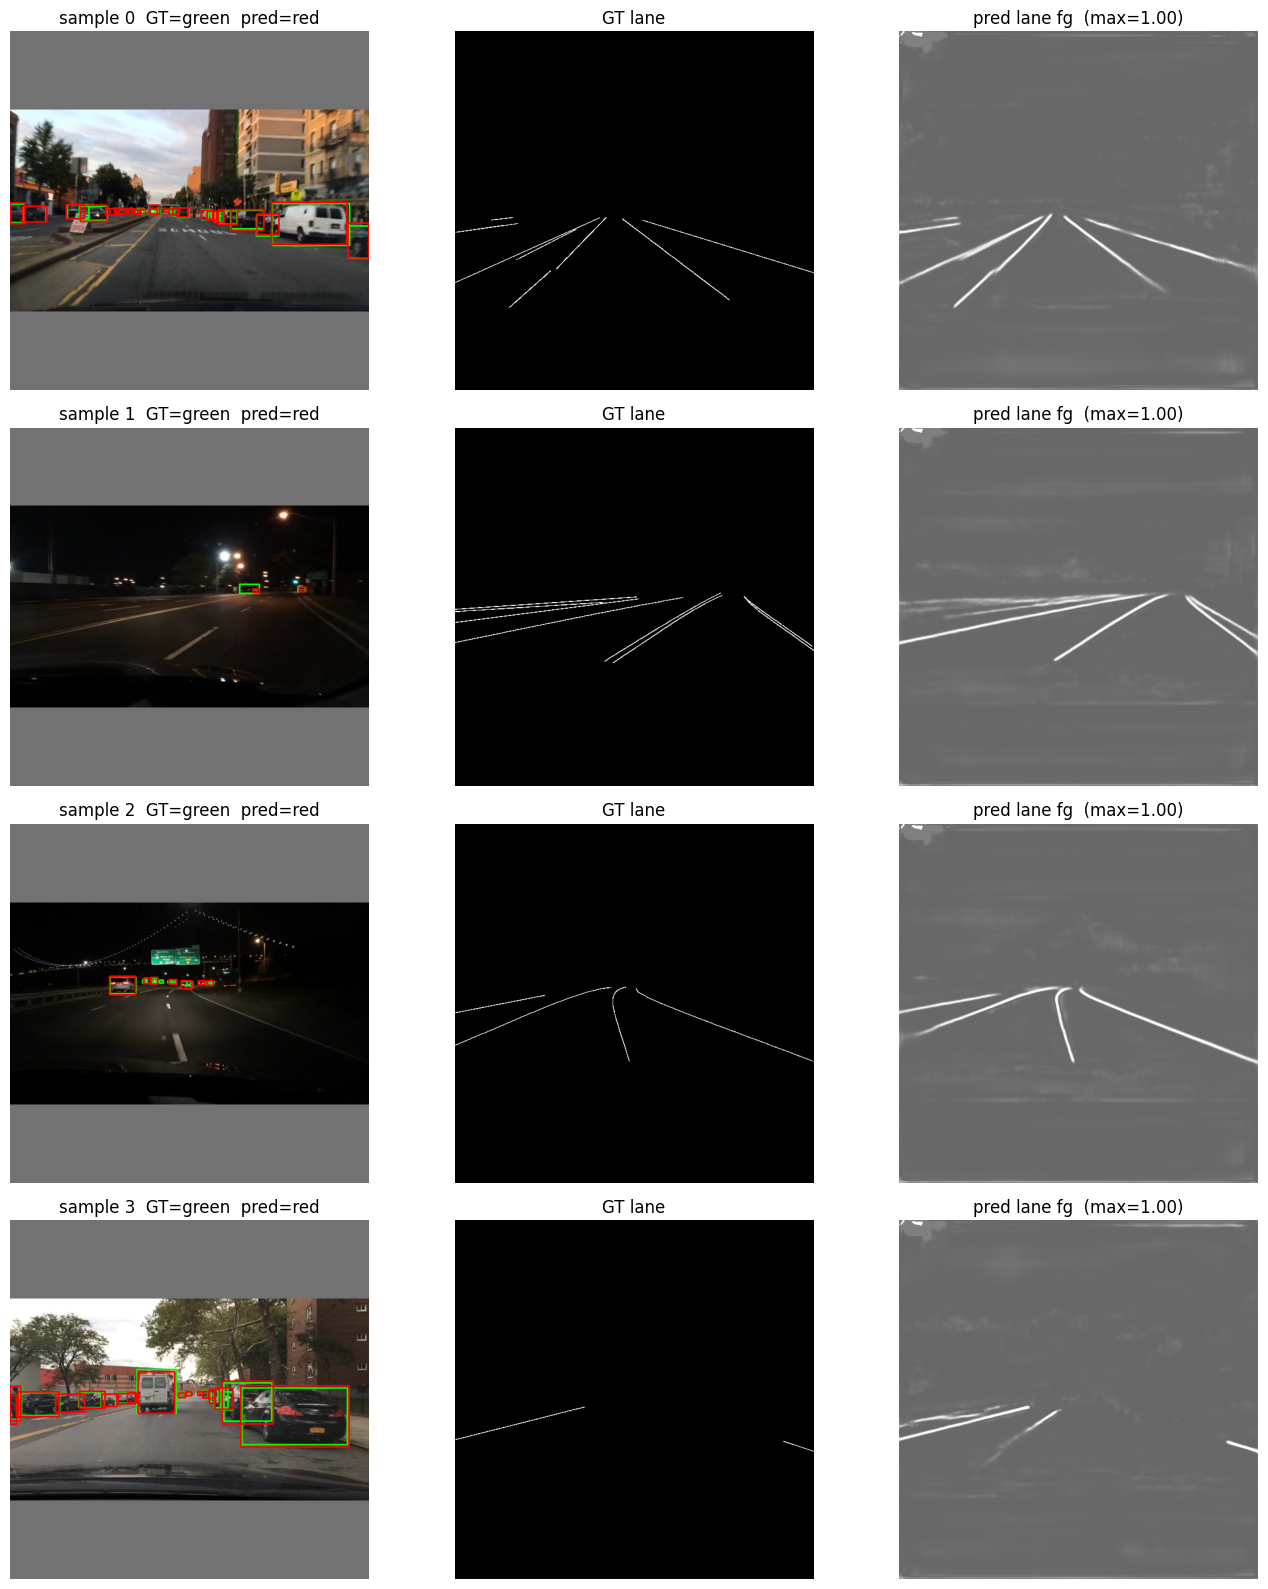

In [7]:
import cv2
from lib.core.general import non_max_suppression, xywh2xyxy

model.eval()
with torch.no_grad():
    det_out, lane_logits = model(img.to(device))
    inf_out, _ = det_out
    outputs = non_max_suppression(inf_out, conf_thres=0.25, iou_thres=0.45)
    fg_prob = torch.sigmoid(lane_logits[:, 0]) if lane_logits.shape[1] == 1 else torch.sigmoid(lane_logits[:, 1]).cpu().numpy()

n_show = 4
fig, axes = plt.subplots(n_show, 3, figsize=(14, 4 * n_show))
for row in range(n_show):
    im = img[row].permute(1, 2, 0).numpy().copy()
    im = np.clip(im, 0, 1)
    im_u8 = (im * 255).astype(np.uint8)
    h, w = im.shape[:2]
    # Draw GT boxes (green)
    det_labels = target[0]
    for lab in det_labels[det_labels[:, 0] == row]:
        _, cls, cx, cy, bw, bh = lab.tolist()
        x1, y1 = int((cx - bw/2) * w), int((cy - bh/2) * h)
        x2, y2 = int((cx + bw/2) * w), int((cy + bh/2) * h)
        cv2.rectangle(im_u8, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Draw pred boxes (red)
    if len(outputs[row]):
        for *xyxy, conf, cls in outputs[row].cpu().numpy():
            x1, y1, x2, y2 = [int(v) for v in xyxy]
            cv2.rectangle(im_u8, (x1, y1), (x2, y2), (255, 0, 0), 2)
    axes[row, 0].imshow(im_u8)
    axes[row, 0].set_title(f'sample {row}  GT=green  pred=red')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(target[1][row, 1].numpy(), cmap='gray')
    axes[row, 1].set_title('GT lane')
    axes[row, 1].axis('off')
    axes[row, 2].imshow(fg_prob[row], cmap='gray', vmin=0, vmax=1)
    axes[row, 2].set_title(f'pred lane fg  (max={fg_prob[row].max():.2f})')
    axes[row, 2].axis('off')
plt.tight_layout()
plt.show()